In [ ]:
import pandas as pd

Task 1 : Data Loading and Understanding

In [ ]:
df_stxn_u= pd.read_excel('/content/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx',
                      sheet_name= 'State_Txn and Users')
df_stxn_s= pd.read_excel('/content/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx',
                      sheet_name= 'State_TxnSplit')
df_st_dd= pd.read_excel('/content/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx',
                      sheet_name= 'State_DeviceData')
df_dtxn_u= pd.read_excel('/content/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx',
                      sheet_name= 'District_Txn and Users')
df_dst_d= pd.read_excel('/content/phonepe-pulse_raw-data_q12018-to-q22021-v0-1-5-1720351752.xlsx',
                      sheet_name= 'District Demographics')

In [ ]:
df_stxn_u.head(5)

In [ ]:
df_stxn_s.tail(10)

In [ ]:
df_st_dd.iloc[10:21,:]

In [ ]:
print("First 10 rows of df_stxn_u:")
display(df_stxn_u.head(10))

In [ ]:
print("Last 10 rows of df_stxn_u:")
display(df_stxn_u.tail(10))

In [ ]:
df_dst_d.iloc[9::10]

In [ ]:
df_stxn_u.describe()


In [ ]:
df_stxn_u.dtypes

In [ ]:
df_stxn_s.describe()

In [ ]:
df_stxn_s.dtypes

In [ ]:
df_st_dd.describe()

In [ ]:
df_st_dd.dtypes

In [ ]:
df_dtxn_u.describe()

In [ ]:
df_dtxn_u.dtypes

In [ ]:
df_dst_d.describe()

In [ ]:
df_dst_d.dtypes

In [ ]:
df_stxn_u.isnull().sum()

In [ ]:
df_stxn_s.isnull().sum()

In [ ]:
df_dtxn_u.isnull().sum()

In [ ]:
df_dst_d.isnull().sum()

In [ ]:
df_st_dd.isnull().sum()

In [ ]:
print(4/10248)

In [ ]:
#Percentage of missing values in 'Amount' column in df_stxn_u = 0.2%
#No missing values in df_stxn_s
#Percentage of missing values in df_dtxn_u: In column 'Code'= 0.2% and in 'ATV'= 0.03%
#No missing values in df_dst_d
#No missing values in df_st_dd



In [ ]:
#Total number of States
df_stxn_u['State'].nunique()

In [ ]:
#Total number of Districts
df_dtxn_u['District'].nunique()

In [ ]:
#State with highest number of districts
df_dtxn_u.groupby('State')['District'].nunique().reset_index().sort_values(by='District', ascending=False)

Exploratory Data Analysis(EDA)

In [ ]:
#Total number of transactions and total transaction amount
df_stxn_u_1= df_stxn_u.groupby('State')[['Amount (INR)','Transactions']].sum().sort_values(by= 'Transactions', ascending= False).reset_index()

In [ ]:
#Most Frequent Transaction Type
df_stxn_s_1= df_stxn_s.groupby(['State','Quarter'])['Transaction Type'].value_counts().reset_index(name= 'Count')
df_stxn_s_1

In [ ]:
most_frequent_transactions= df_stxn_s_1.loc[df_stxn_s_1.groupby(['State', 'Quarter'])['Count'].idxmax()]

In [ ]:
most_frequent_transactions

In [ ]:
#Brand with the highest number of registered users in each state
highest_registered_users= df_st_dd.groupby('State')['Brand'].value_counts().reset_index(name= 'Count')

In [ ]:
highest_registered_users= highest_registered_users.loc[highest_registered_users.groupby('State')['Count'].idxmax()]

In [ ]:
highest_registered_users

In [ ]:
#Top district per state based on population
max_pop_dst= df_dst_d[['State','District','Population']]

In [ ]:
max_pop_dst= max_pop_dst.loc[max_pop_dst.groupby('State')['Population'].idxmax()].reset_index()

In [ ]:
max_pop_dst.sort_values(by= 'Population', ascending= False, inplace= True)

In [ ]:
max_pop_dst= max_pop_dst.reset_index()

In [ ]:
max_pop_dst

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Column chart depicting the district with the highest population for each state
plt.figure(figsize=(14,8))
max_pop_dst.plot(kind= 'bar', color= 'skyblue')
plt.title('District with the highest population for each state')
plt.xlabel('District')
plt.ylabel('Population')
plt.xticks(rotation= 60)
plt.show()

In [ ]:
#Average transaction for each state
avg_trnsxn_value= df_stxn_u.groupby('State')['ATV (INR)'].mean().reset_index().sort_values(by= 'ATV (INR)', ascending= False)

In [ ]:
avg_trnsxn_value= avg_trnsxn_value.reset_index().drop(columns= 'index')

In [ ]:
avg_trnsxn_value

In [ ]:
#App opens over the years and quarters for each state
state_app_opens= df_stxn_u.groupby(['State','Year','Quarter'])['App Opens'].sum().reset_index()

In [ ]:
state_app_opens= state_app_opens.reset_index()

In [ ]:
state_app_opens= state_app_opens.sort_values(by= ['State', 'Year', 'Quarter'])

In [ ]:
#Line plot for the number of app opens over time for the state Haryana
state_app_opens_hry= state_app_opens[state_app_opens['State']=='Haryana']

In [ ]:
state_app_opens_hry_graph= state_app_opens_hry.groupby(['Year','Quarter'])['App Opens'].sum().reset_index()


In [ ]:
state_app_opens_hry_graph['Yr_Qtr']= state_app_opens_hry_graph['Year'].astype(str)+'-'+state_app_opens_hry_graph['Quarter'].astype(str)

In [ ]:
state_app_opens_hry_graph= state_app_opens_hry_graph.drop(columns= ['Year','Quarter'])


In [ ]:
state_app_opens_hry_graph

In [ ]:
plt.plot(state_app_opens_hry_graph['Yr_Qtr'], state_app_opens_hry_graph['App Opens'],label= 'Haryana',
         marker= 'o')
plt.xlabel('Year')
plt.ylabel('App Opens')
plt.xticks(rotation= 45)
plt.legend()
plt.show()

In [ ]:
#Bar chart showing the distribution of different transaction types for each state
df_stxn_s_f= df_stxn_s[df_stxn_s['Quarter']==4]

In [ ]:
df_stxn_s_f.dtypes

In [ ]:
df_stxn_s_f.groupby(['State','Transaction Type'])['Transactions'].sum().reset_index()

In [ ]:
pivot_df= pd.pivot_table(df_stxn_s_f, index= 'State', columns= 'Transaction Type', values= 'Transactions').fillna(0)

In [ ]:
pivot_df.plot(kind= 'bar', figsize=(12,10))
plt.xlabel('State')
plt.ylabel('Transactions')
plt.title('Distribution of transaction types for each state')
plt.tight_layout()
plt.show()

In [ ]:
unique_mapping= df_dst_d[['District', 'Code']].drop_duplicates()

In [ ]:
unique_mapping

In [ ]:
#Unique mapping between district name and district code
unique_mapping.to_csv('unique_mapping.csv', index= False)

Data Quality Checks

In [ ]:
district_level= df_dtxn_u.groupby('State')[['Transactions', 'Registered Users', 'Amount (INR)']].sum().reset_index()

In [ ]:
state_level= df_stxn_u.groupby('State')[['Transactions', 'Registered Users', 'Amount (INR)']].sum().reset_index()

In [ ]:
district_level.equals(state_level)

In [ ]:
district_level.compare(state_level)

In [ ]:
district_level[district_level['Amount (INR)'] != state_level['Amount (INR)']]

Data Merging and Advanced Analysis

In [ ]:
#Ratio of registered users to the population for each state
merged_dataset= pd.merge(df_stxn_u, df_dst_d, on= 'State', how= 'inner')

In [ ]:
merged_dataset_g= merged_dataset.groupby('State')[['Registered Users', 'Population']].sum()

In [ ]:
merged_dataset_g= merged_dataset_g.reset_index()

In [ ]:
merged_dataset_g['Ratio']= merged_dataset_g['Registered Users']/merged_dataset_g['Population']

In [ ]:
merged_dataset_g= merged_dataset_g.drop(columns= ['Registered Users', 'Population'])

In [ ]:
merged_dataset_g

In [ ]:
#Column chart for the ratio of users to population by state
merged_dataset_g.plot(kind= 'bar', figsize= (12,10))
plt.xlabel('State')
plt.ylabel('Ratio')
plt.title('Ratio of Registered Users to Population')
plt.show()

In [ ]:
#Correlating population density with transaction volume
merged_dataset_d= pd.merge(df_dtxn_u, df_dst_d, on= 'District', how= 'inner')

In [ ]:
merged_dataset_d= merged_dataset_d.groupby('District')['Transactions'].sum()

In [ ]:
merged_dataset_d= merged_dataset_d.reset_index()

In [ ]:
df_m= pd.merge(merged_dataset_d, df_dst_d, on= 'District', how= 'inner')
suffixes= ('_d', '_dst')

In [ ]:
corr= df_m['Transactions'].corr(df_m['Density'])

In [ ]:
corr

np.float64(0.41220370977028603)

In [ ]:
plt.scatter(df_m['Transactions'], df_m['Density'])
plt.xlabel('Density')
plt.ylabel('Transactions')
plt.title('Correlation between Density and Transactions')
plt.legend()
plt.show()

In [ ]:
#Average transaction amount per user for each state
df_a= df_stxn_u.groupby('State')[['Amount (INR)', 'Registered Users']].sum()


In [ ]:
df_a['avg_trxn']= df_a['Amount (INR)']/df_a['Registered Users']

In [ ]:
df_a= df_a.drop(columns= ['Amount (INR)', 'Registered Users'])

In [ ]:
df_a= df_a.reset_index()

In [ ]:
df_a

In [ ]:
#Device brand usage ratio
mrgd_tble= pd.merge(df_stxn_u, df_st_dd, on= 'State', how= 'inner')

In [ ]:
mrgd_tble.head(3)

In [ ]:
df_b= df_st_dd.groupby(['State','Brand'])['Registered Users'].sum().reset_index()


In [ ]:
df_b_1= df_stxn_u.groupby('State')['Registered Users'].sum().reset_index()

In [ ]:
mgd_tbl= pd.merge(df_b, df_b_1, on= 'State', how= 'inner')

In [ ]:
mgd_tbl['Ratio']= mgd_tbl['Registered Users_x']/mgd_tbl['Registered Users_y']

In [ ]:
mgd_tbl= mgd_tbl.drop(columns= ['Registered Users_x', 'Registered Users_y'])

In [ ]:
mgd_tbl

In [ ]:
plt.figure(figsize= (12,10))
mgd_tbl.plot(kind= 'bar', x= 'State', y= 'Ratio')
plt.xlabel('State')
plt.ylabel('Ratio')
plt.title('Device brand Ratio')

Data Visualisation

In [ ]:
#Line plot for total transactions and amount over time for state Haryana
df_stxn_u[df_stxn_u['State']=='Haryana']

In [ ]:
df_stxn_ug= df_stxn_u.groupby(['State','Year','Quarter'])[['Transactions','Amount (INR)']].sum().reset_index()

In [ ]:
df_stxn_ug_h= df_stxn_ug[df_stxn_ug['State']=='Haryana']

In [ ]:
df_stxn_ug_h

/tmp/ipython-input-3067872800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stxn_ug_h['Yr_Qtr']= df_stxn_ug_h['Year'].astype(str)+'-'+df_stxn_ug_h['Quarter'].astype(str)


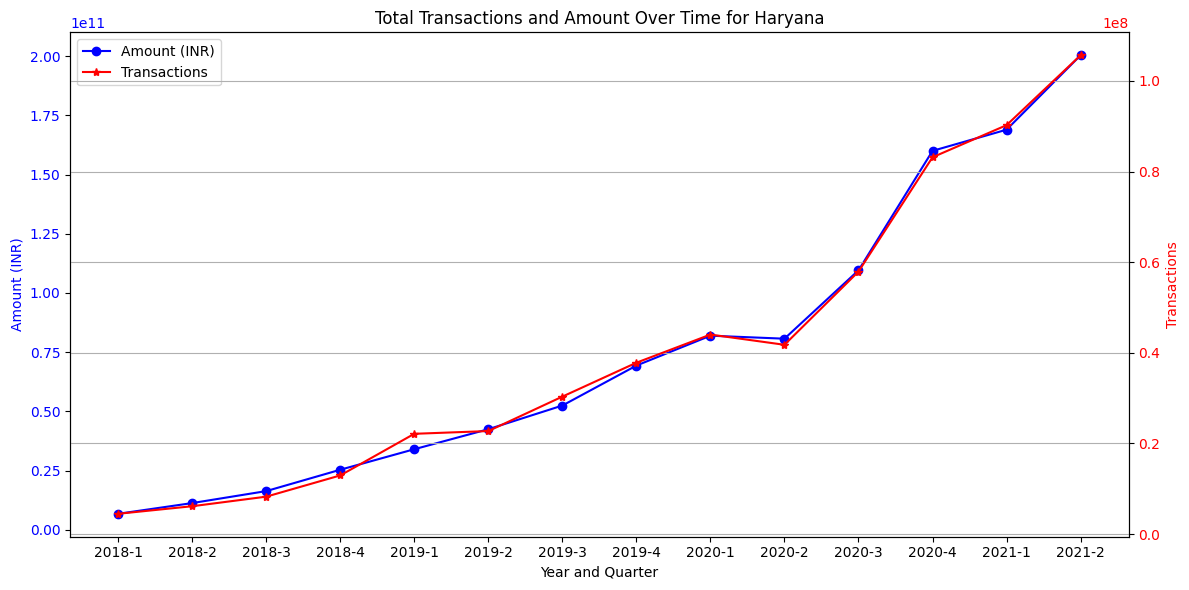

In [ ]:
df_stxn_ug_h['Yr_Qtr']= df_stxn_ug_h['Year'].astype(str)+'-'+df_stxn_ug_h['Quarter'].astype(str)
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_stxn_ug_h['Yr_Qtr'], df_stxn_ug_h['Amount (INR)'], label='Amount (INR)', marker='o', color='blue')
ax1.set_xlabel('Year and Quarter')
ax1.set_ylabel('Amount (INR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()  # Create a second y-axis that shares the same x-axis
ax2.plot(df_stxn_ug_h['Yr_Qtr'], df_stxn_ug_h['Transactions'], label='Transactions', marker='*', color='red')
ax2.set_ylabel('Transactions', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Total Transactions and Amount Over Time for Haryana')
plt.xticks(rotation=45)

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Pie chart showing the distribution of different transaction types for Haryana
df_stxn_s_h= df_stxn_s[df_stxn_s['State']=='Haryana']

In [ ]:
df_stxn_s_h1= df_stxn_s_h[df_stxn_s_h['Quarter']==1]

In [ ]:
df_pie= df_stxn_s_h1.groupby(['Transaction Type'])['Transactions'].sum()

In [ ]:
df_pie= df_pie.reset_index()

In [ ]:
df_pie

In [ ]:
df_pie.plot(kind= 'pie', y='Transactions', labels= df_pie['Transaction Type'], autopct= '%1.1f%%',startangle= 140, pctdistance=0.85, labeldistance=1.1)
plt.title('Distribution of Transaction Types in Haryana')
plt.axis('equal')
plt.show()

In [ ]:
#Bar plot for population density of districts in Haryana
df_dst_d_h= df_dst_d[df_dst_d['State']=='Haryana']

In [ ]:
df_dst_d_h.plot(kind= 'bar', x= 'District', y= 'Density', color= 'Green')
plt.xlabel('District')
plt.ylabel('Density')
plt.title('Population Density')

Insights and Conclusions

In [ ]:
df_line= df_stxn_s.groupby('Year')[['Transactions','Amount (INR)']].sum()

In [ ]:
df_line= df_line.reset_index()

In [ ]:
plt.plot(df_line['Year'], df_line['Amount (INR)'], label= 'Amount (INR)', marker= 'o')
plt.legend()
plt.show()